# Reproducing the key calculations of the QPD reactor-CEvNS paper

**Manuscript:** *Reconstructed-energy background spectra for a Quantum-Parity-Detector germanium wafer:
reactor CEvNS, cosmic muons, and environmental gammas.*

This notebook reproduces the load-bearing numbers, anchors, and figures of the paper by calling the
same tested pipeline in `src/qpd_potential/`. Cheap analytic quantities are recomputed live; the
expensive Monte-Carlo response matrix and the deposited background spectra are loaded from the
committed artifacts (the paper's figures use higher MC statistics than a notebook would run
interactively). Every printed value is cross-checked against the number quoted in the manuscript.

Sections follow the paper:
1. Setup & provenance
2. Reactor flux and CEvNS rate (Sec. III)
3. Cosmic-muon background (Sec. IV.A)
4. Environmental-gamma Compton background (Sec. IV.B)
5. QPD response, saturation, and the crossover band (Sec. V)
6. Reconstructed-energy spectra and landing report (Sec. VI)
7. Summary: computed vs. paper-quoted anchors

## 1. Setup & provenance

Locate the repo root, put `src/` on the path, and print the frozen configuration parameters.

In [1]:
import os, sys, numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

# Walk up from the CWD to the repo root (the dir containing src/qpd_potential).
_p = os.getcwd()
while _p != os.path.dirname(_p):
    if os.path.isdir(os.path.join(_p, "src", "qpd_potential")):
        break
    _p = os.path.dirname(_p)
ROOT = _p
sys.path.insert(0, os.path.join(ROOT, "src"))
os.chdir(ROOT)
print("repo root:", ROOT)

from qpd_potential import params
print("\nFrozen stage-1 configuration:")
_cfg = [("thermal power", params.REACTOR_POWER), ("standoff", params.STANDOFF),
        ("wafer mass", params.WAFER_MASS), ("Ge atoms/kg", params.GE_ATOMS_PER_KG),
        ("N sensors", params.N_SENSORS), ("efficiency eps", params.EPSILON),
        ("dead time tau_d", params.TAU_D), ("sampling", params.SAMPLING)]
for label, pobj in _cfg:
    print(f"  {label:>16s} = {pobj.value:<12g} {pobj.units}")
print("  default censoring =", params.DEFAULT_CENSORING)

repo root: /Users/lanqingyuan/Documents/GitHub/qpd_potential/.claude/worktrees/qpd-cevns-muon-spectrum-aaa8da

Frozen stage-1 configuration:
     thermal power = 3            GW_th
          standoff = 25           m
        wafer mass = 109.9        g
       Ge atoms/kg = 8.29e+24     atoms/kg
         N sensors = 10300        
    efficiency eps = 0.5          
   dead time tau_d = 4e-05        s
          sampling = 2e-05        s
  default censoring = non_paralyzable


In [2]:
def check(label, computed, paper, tol_pct=None, fmt="{:.4g}"):
    '''Print a computed value next to the paper-quoted value with % difference.'''
    try:
        diff = 100.0 * (computed - paper) / paper if paper else float("nan")
        flag = "" if (tol_pct is None or abs(diff) <= tol_pct) else "  <-- CHECK"
        print(f"  {label:<46s} computed={fmt.format(computed):>12s}  paper={fmt.format(paper):>12s}  ({diff:+.2f}%){flag}")
    except Exception as e:
        print(f"  {label}: {e}")

## 2. Reactor flux and CEvNS rate (Sec. III)

The reactor flux $\Phi(E_\nu)$ (frozen Phase-2 table), the Freedman coherent cross section
$d\sigma/dT$ with the Lewin–Smith Helm form factor, the isotope-summed deposited rate $dR/dT$,
and the absolute-normalization benchmark against Billard *et al.* (2017).

In [3]:
from qpd_potential import cevns

flux = cevns.ReactorFlux()
int_flux = np.trapz(flux.phi, flux.E)      # nu / cm^2 / s
print("Reactor flux:")
print(f"  E_nu grid: {flux.E_min:.3g}-{flux.E_max:.3g} MeV")
check("integrated flux [nu/cm^2/s]", int_flux, 7.5e12, tol_pct=8, fmt="{:.3g}")
check("REACTOR_FLUX param [nu/cm^2/s]", params.REACTOR_FLUX.value, 7.5e12, tol_pct=8, fmt="{:.3g}")

print("\nCoherent cross section (closed form):")
sig72 = cevns.sigma_tot_MeV(4.0, 32, 40)   # 72Ge at 4 MeV
check("sigma(72Ge, 4 MeV) [cm^2]", sig72, 1.0e-40, tol_pct=1, fmt="{:.4e}")
print(f"  weak charge Q_W(72Ge) = {cevns.weak_charge(32, 40):.3f}  (N^2-dominated)")

Reactor flux:
  E_nu grid: 0.1-10 MeV
  integrated flux [nu/cm^2/s]                    computed=     7.5e+12  paper=     7.5e+12  (+0.04%)
  REACTOR_FLUX param [nu/cm^2/s]                 computed=     7.5e+12  paper=     7.5e+12  (+0.00%)

Coherent cross section (closed form):
  sigma(72Ge, 4 MeV) [cm^2]                      computed=  1.0026e-40  paper=  1.0000e-40  (+0.26%)
  weak charge Q_W(72Ge) = 38.554  (N^2-dominated)


In [4]:
# Deposited-energy differential rate dR/dT and the integrated rate above 50 eV_nr.
R50 = cevns.integrated_rate_above(flux, 50.0)
print("Deposited CEvNS rate:")
check("integral dR/dT above 50 eV_nr [/kg/day]", R50, 67.8, tol_pct=3)

Deposited CEvNS rate:
  integral dR/dT above 50 eV_nr [/kg/day]        computed=       67.75  paper=        67.8  (-0.07%)


In [5]:
# Absolute-normalization benchmark: reproduce Billard et al. (2017) Table 1.
bill = cevns.reproduce_billard()
k = bill["k"]
print("Billard geometry+power rescale:")
check("k factor", k, 0.01112, tol_pct=1, fmt="{:.5f}")
print(f"  1/k = {1.0/k:.2f}  (overshoot factor without k)\n")
paper_rates = {50.0: 0.742, 100.0: 0.501, 200.0: 0.257}
print("  threshold   computed   paper(within-2.4%)   Billard-Table1")
billard_t1 = {50.0: 0.76, 100.0: 0.51, 200.0: 0.26}
for T0 in (50.0, 100.0, 200.0):
    print(f"    {T0:>5.0f} eV   {bill['rates_with_k'][T0]:.4f}     {paper_rates[T0]:.3f}"
          f"                {billard_t1[T0]:.2f}   ({bill['percent_vs_billard'][T0]:+.2f}% vs T1)")

Billard geometry+power rescale:
  k factor                                       computed=     0.01112  paper=     0.01112  (-0.00%)
  1/k = 89.93  (overshoot factor without k)

  threshold   computed   paper(within-2.4%)   Billard-Table1
       50 eV   0.7415     0.742                0.76   (-2.43% vs T1)
      100 eV   0.5009     0.501                0.51   (-1.79% vs T1)
      200 eV   0.2567     0.257                0.26   (-1.25% vs T1)


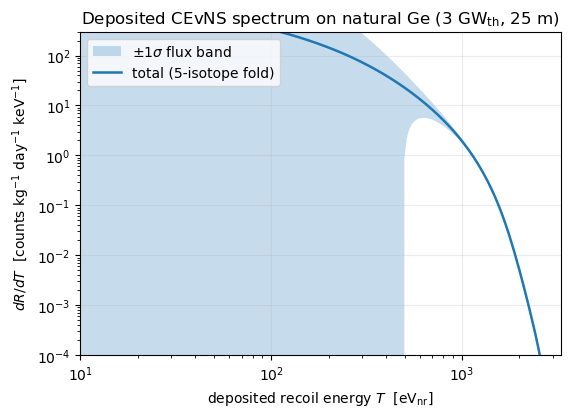

In [6]:
# Figure: deposited nuclear-recoil differential CEvNS spectrum dR/dT (paper Fig. 4).
T_eV, per_iso, total, band = cevns.build_dRdT_table(flux, n_grid=220)
fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.fill_between(T_eV, total*(1-band), total*(1+band), color="#1f77b4", alpha=0.25, lw=0,
                label=r"$\pm1\sigma$ flux band")
ax.plot(T_eV, total, color="#1f77b4", lw=1.8, label="total (5-isotope fold)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(10, 3300); ax.set_ylim(1e-4, 3e2)
ax.set_xlabel(r"deposited recoil energy $T$  [eV$_{\rm nr}$]")
ax.set_ylabel(r"$dR/dT$  [counts kg$^{-1}$ day$^{-1}$ keV$^{-1}$]")
ax.set_title("Deposited CEvNS spectrum on natural Ge (3 GW$_{\\rm th}$, 25 m)")
ax.grid(True, which="major", alpha=0.25); ax.legend()
plt.show()

## 3. Cosmic-muon background (Sec. IV.A)

Wafer chord geometry (Cauchy mean chord $\langle\ell\rangle=4V/S$), the Landau width $\xi$ and
most-probable deposit for a vertical minimum-ionizing muon, and the total through-wafer muon rate
from the Gaisser–Guan flux fold. A modest Monte-Carlo run (2e6 samples) reproduces the rate and MPV;
the paper uses higher statistics only to smooth the deposited-spectrum tail.

In [7]:
from qpd_potential import wafer_geometry as geom, muon_deposit as mu

print("Wafer chord geometry:")
check("Cauchy mean chord 4V/S [cm]", geom.cauchy_mean_chord(), 0.385, tol_pct=1, fmt="{:.3f}")
print(f"  vertical chord = {geom.CHORD_VERTICAL:.2f} cm,  space diagonal = {geom.CHORD_DIAGONAL:.2f} cm")

# Landau width for a vertical MIP: x = rho * L_z (g/cm^2), beta^2 ~ 1.
x_mip = geom.RHO * geom.CHORD_VERTICAL
xi_mip = float(mu.xi_width(np.array([x_mip]), np.array([1.0]))[0])
print("\nLandau parameters (vertical MIP):")
print(f"  mass thickness x = rho*L_z = {x_mip:.4f} g/cm^2")
check("xi width [MeV]", xi_mip, 0.072, tol_pct=3, fmt="{:.4f}")

Wafer chord geometry:
  Cauchy mean chord 4V/S [cm]                    computed=       0.385  paper=       0.385  (-0.04%)
  vertical chord = 0.20 cm,  space diagonal = 14.37 cm

Landau parameters (vertical MIP):
  mass thickness x = rho*L_z = 1.0646 g/cm^2
  xi width [MeV]                                 computed=      0.0720  paper=      0.0720  (+0.03%)


In [8]:
# Total muon rate + MPV/mean deposit from the Gaisser-Guan fold (modest MC).
spec_mu = mu.run_muon_mc(n_samples=2_000_000, seed=20260720)
print("Muon fold (2e6 MC samples):")
check("total muon rate [Hz]", spec_mu.rate_hz, 1.366, tol_pct=30)
check("vertical MPV deposit [MeV]", spec_mu.vertical_mpv_mev, 1.23, tol_pct=8)
check("vertical mean deposit [MeV]", spec_mu.vertical_mean_mev, 1.46, tol_pct=5)
print(f"  (paper quotes 1.366 Hz at N=1e9; rate converges fast, spectrum tail needs the stats)")

Muon fold (2e6 MC samples):
  total muon rate [Hz]                           computed=        1.37  paper=       1.366  (+0.29%)
  vertical MPV deposit [MeV]                     computed=       1.216  paper=        1.23  (-1.16%)
  vertical mean deposit [MeV]                    computed=       1.459  paper=        1.46  (-0.10%)
  (paper quotes 1.366 Hz at N=1e9; rate converges fast, spectrum tail needs the stats)


## 4. Environmental-gamma Compton background (Sec. IV.B)

Radiogenic $^{40}$K / $^{238}$U / $^{232}$Th line list, the Compton edges (fixed by kinematics),
the total single-scatter interaction rate, and its independent $\Phi\,\sigma_{\rm KN}\,N_e$ anchor.
The absolute rate carries a site-dependent factor-of-2 band (Sec. IV); the edges are exact.

In [9]:
from qpd_potential import compton_source as cs, compton_deposit as cd

print("Compton edges (kinematic, model-independent):")
for Eg, name, paper_edge in [(1460.8, "40K 1461", 1243.0), (1764.5, "214Bi 1764", 1541.0),
                             (2614.5, "208Tl 2615", 2382.0)]:
    check(f"edge({name}) [keV]", cs.compton_edge_kev(Eg), paper_edge, tol_pct=1, fmt="{:.0f}")

lines = cs.load_gamma_lines()
rate = sum(cd.line_interaction_rate_hz(l.flux_cm2_s, l.energy_keV) for l in lines)
anchor = sum(cd.line_rate_anchor_hz(l.flux_cm2_s, l.energy_keV) for l in lines)
print(f"\nSingle-scatter interaction rate ({len(lines)} lines):")
check("bound single-scatter rate [Hz]", rate, 0.267, tol_pct=5, fmt="{:.3f}")
check("Phi*sigma_KN*N_e anchor [Hz]", anchor, 0.273, tol_pct=5, fmt="{:.3f}")
print(f"  ratio rate/anchor = {rate/anchor:.3f}  (paper: 0.98)")
check("double-scatter fraction @1 MeV", cs.double_scatter_fraction(1000.0), 0.014, tol_pct=25, fmt="{:.4f}")

Compton edges (kinematic, model-independent):
  edge(40K 1461) [keV]                           computed=        1243  paper=        1243  (+0.03%)
  edge(214Bi 1764) [keV]                         computed=        1541  paper=        1541  (+0.02%)
  edge(208Tl 2615) [keV]                         computed=        2382  paper=        2382  (-0.01%)

Single-scatter interaction rate (16 lines):
  bound single-scatter rate [Hz]                 computed=       0.268  paper=       0.267  (+0.55%)
  Phi*sigma_KN*N_e anchor [Hz]                   computed=       0.273  paper=       0.273  (+0.02%)
  ratio rate/anchor = 0.983  (paper: 0.98)
  double-scatter fraction @1 MeV                 computed=      0.0138  paper=      0.0140  (-1.58%)


## 5. QPD response, saturation, and the crossover band (Sec. V)

The two trapping designs (Table II parameters), the per-sensor saturation onset, the crossover
deposit energy and its $f_{\rm prompt}/r$ band, the whole-array plateau, and the reconstructed-energy
plateau at the 197 MeV muon endpoint (from the committed Monte-Carlo response matrix).

In [10]:
from qpd_potential import energy_scale as es, response as resp, response_matrix as rm

print("Trap designs (Ramanathan Table II):")
print(f"  {'design':<8s} {'Delta_tr[ueV]':>12s} {'V_tr[um^3]':>10s} {'K[kHz um^3]':>12s} {'p':>6s}")
for name, d in params.DESIGNS.items():
    print(f"  {name:<8s} {d.delta_tr.value*1e6:>12.0f} {d.v_tr.value:>10.0f} "
          f"{d.K.value/1e3:>12.0f} {es.peak_factor(d):>6.2f}")

print("\nPer-sensor saturation onset E_sensor [eV]:")
onset_paper = {"Ta->Al": 1.27, "Al->Hf": 0.77}
for name, d in params.DESIGNS.items():
    check(f"E_onset ({name})", es.saturation_onset_energy(d), onset_paper[name], tol_pct=3, fmt="{:.2f}")

Trap designs (Ramanathan Table II):
  design   Delta_tr[ueV] V_tr[um^3]  K[kHz um^3]      p
  Ta->Al            190        100            3   0.25
  Al->Hf             40       1000           20   0.13

Per-sensor saturation onset E_sensor [eV]:
  E_onset (Ta->Al)                               computed=        1.27  paper=        1.27  (-0.26%)
  E_onset (Al->Hf)                               computed=        0.77  paper=        0.77  (-0.10%)


In [11]:
# Crossover band (default point, scan, whole-array plateau) per design.
xover_paper = {"Ta->Al": (52.9, 18.6e3), "Al->Hf": (32.1, 11.3e3)}
for name, d in params.DESIGNS.items():
    cb = resp.crossover_band(d)
    dp, wap = xover_paper[name]
    print(f"{name}:")
    check("  crossover default point [eV]", cb["default_point_eV"], dp, tol_pct=3)
    check("  whole-array plateau [eV]", cb["whole_array_plateau_default_eV"], wap, tol_pct=3, fmt="{:.4g}")
    print(f"    scan band: {cb['band_min_eV']:.1f} eV -> {cb['band_max_eV']/1e3:.2f} keV  "
          f"(f_prompt in {cb['f_prompt_range']}, r in {cb['r_range']})")

Ta->Al:
    crossover default point [eV]                 computed=       52.91  paper=        52.9  (+0.01%)
    whole-array plateau [eV]                     computed=   1.864e+04  paper=    1.86e+04  (+0.20%)
    scan band: 8.0 eV -> 0.93 keV  (f_prompt in (0.1, 0.5), r in (1.0, 5.0))
Al->Hf:
    crossover default point [eV]                 computed=       32.13  paper=        32.1  (+0.09%)
    whole-array plateau [eV]                     computed=   1.132e+04  paper=    1.13e+04  (+0.17%)
    scan band: 4.8 eV -> 0.57 keV  (f_prompt in (0.1, 0.5), r in (1.0, 5.0))


Response matrix E_rec plateau at the 197 MeV deposit endpoint:
    E_rec endpoint (Ta->Al) [keV]                computed=        34.8  paper=        34.8  (-0.10%)
    E_rec endpoint (Al->Hf) [keV]                computed=        26.8  paper=        26.8  (+0.17%)


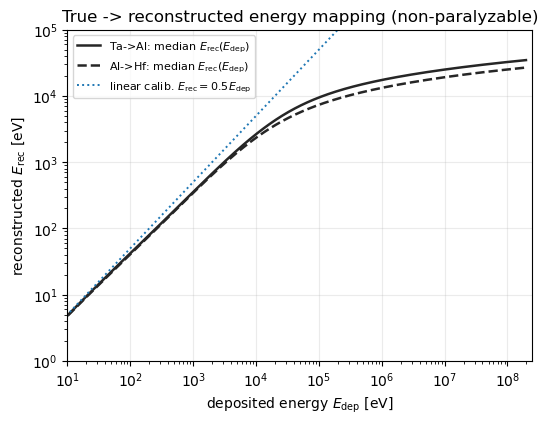

In [12]:
# Reconstructed-energy plateau at the 197 MeV muon endpoint, from the committed response matrix.
endpoint_paper = {"Ta->Al": 34.8, "Al->Hf": 26.8}
print("Response matrix E_rec plateau at the 197 MeV deposit endpoint:")
for name in rm.DESIGN_FILE:
    z = np.load(os.path.join(rm._ARTIFACT_DIR, rm.DESIGN_FILE[name]))
    erec_end_keV = float(z["E_rec_median_non_paralyzable_eV"][-1]) / 1e3
    check(f"  E_rec endpoint ({name}) [keV]", erec_end_keV, endpoint_paper[name], tol_pct=3, fmt="{:.1f}")

# Figure: the true->reconstructed mapping (paper Fig. 3) from the committed matrix.
fig, ax = plt.subplots(figsize=(6.0, 4.3))
ls = {"Ta->Al": "-", "Al->Hf": "--"}
for name in rm.DESIGN_FILE:
    z = np.load(os.path.join(rm._ARTIFACT_DIR, rm.DESIGN_FILE[name]))
    ax.plot(z["E_dep_centers_eV"], z["E_rec_median_non_paralyzable_eV"], ls=ls[name],
            color="0.15", lw=1.8, label=f"{name}: median $E_{{\\rm rec}}(E_{{\\rm dep}})$")
ed = np.array([5.0, 5e5])
ax.plot(ed, 0.5*ed, color="#1f77b4", ls=":", lw=1.4, label=r"linear calib. $E_{\rm rec}=0.5 E_{\rm dep}$")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(10, 2.5e8); ax.set_ylim(1, 1e5)
ax.set_xlabel(r"deposited energy $E_{\rm dep}$ [eV]"); ax.set_ylabel(r"reconstructed $E_{\rm rec}$ [eV]")
ax.set_title("True -> reconstructed energy mapping (non-paralyzable)")
ax.grid(True, which="major", alpha=0.25); ax.legend(loc="upper left", fontsize=8)
plt.show()

## 6. Reconstructed-energy spectra and landing report (Sec. VI)

Fold the three deposited spectra through the non-paralyzable response matrix and read off the
reconstructed-energy landing: the CEvNS signal peak (tens of eV), the muon pile-up and Compton
peak (tens of keV), the fraction of CEvNS counts below 100 eV, counts conservation, and the
in-wafer pileup occupancy.

In [13]:
from qpd_potential import fold

report = fold.landing_report()
peak_paper = {("cevns","Ta->Al"): 0.042, ("muon","Ta->Al"): 18.8, ("compton","Ta->Al"): 16.8,
              ("cevns","Al->Hf"): 0.042, ("muon","Al->Hf"): 15.0, ("compton","Al->Hf"): 13.3}
print("Reconstructed-energy peaks [keV] and integrated rates [counts/kg/day]:")
for design in report["designs"]:
    print(f"\n {design}:")
    for ch in ("cevns", "muon", "compton"):
        e = report["designs"][design][ch]
        check(f"  {ch} peak E_rec [keV]", e["peak_Erec_keV"], peak_paper[(ch,design)],
              tol_pct=8, fmt="{:.3g}")
    cev = report["designs"][design]["cevns"]
    print(f"    CEvNS integrated rate = {cev['integrated_rate_cts_per_kg_day']:.1f} /kg/day, "
          f"frac below 100 eV = {cev['frac_below_eV'][100.0]:.2f}")

Reconstructed-energy peaks [keV] and integrated rates [counts/kg/day]:

 Ta->Al:
    cevns peak E_rec [keV]                       computed=      0.0422  paper=       0.042  (+0.40%)
    muon peak E_rec [keV]                        computed=        18.8  paper=        18.8  (+0.19%)
    compton peak E_rec [keV]                     computed=        16.8  paper=        16.8  (-0.07%)
    CEvNS integrated rate = 109.6 /kg/day, frac below 100 eV = 0.85

 Al->Hf:
    cevns peak E_rec [keV]                       computed=      0.0422  paper=       0.042  (+0.40%)
    muon peak E_rec [keV]                        computed=          15  paper=          15  (-0.25%)
    compton peak E_rec [keV]                     computed=        13.3  paper=        13.3  (+0.26%)
    CEvNS integrated rate = 109.6 /kg/day, frac below 100 eV = 0.86


In [14]:
# Counts conservation of the fold, and the in-wafer pileup occupancy.
res = fold.run_fold("Ta->Al", write=False)
cc = fold.counts_conservation(res)
print("Counts conservation (fold preserves per-channel counts):")
for ch, v in cc.items():
    print(f"  {ch:<8s} rel residual = {v['rel']:.1e}")

rate_mu, rate_comp = 1.366, 0.267
R_tot = rate_mu + rate_comp
tau = 20e-6
print(f"\nIn-wafer event rate = {R_tot:.3f} Hz (muon {rate_mu} + Compton {rate_comp})")
check("mean inter-event time [s]", 1.0/R_tot, 0.61, tol_pct=5, fmt="{:.2f}")
check("pileup occupancy R*tau @20 us", R_tot*tau, 3.3e-5, tol_pct=10, fmt="{:.1e}")

Counts conservation (fold preserves per-channel counts):
  cevns    rel residual = 1.3e-16
  muon     rel residual = 0.0e+00
  compton  rel residual = 0.0e+00

In-wafer event rate = 1.633 Hz (muon 1.366 + Compton 0.267)
  mean inter-event time [s]                      computed=        0.61  paper=        0.61  (+0.39%)
  pileup occupancy R*tau @20 us                  computed=     3.3e-05  paper=     3.3e-05  (-1.03%)


**Deposited (true) vs. reconstructed overlay (paper Fig. 1).** The deposited, pre-reconstruction
spectra are produced by `fold.read_cevns()` (CEvNS $dR/dT$) and `fold.read_channel_dRdEdep()`
(muon and Compton $dR/dE_{\rm dep}$); they are design-independent because the deposit precedes the
QPD response. Overlaying them (dashed) on the reconstructed spectra (solid) exposes the response:
the MeV-scale muon deposits are compressed onto the single tens-of-keV reconstructed pile-up, while
the tens-of-eV CEvNS deposits map linearly (offset only by $E_{\rm rec}=0.5\,E_{\rm dep}$). The exact
paper figure is written by `fold.make_spectra_figure()`.

deposited muon E_dep range [keV]: 0.0101 - 1.97e+05  (up to the 197 MeV endpoint)


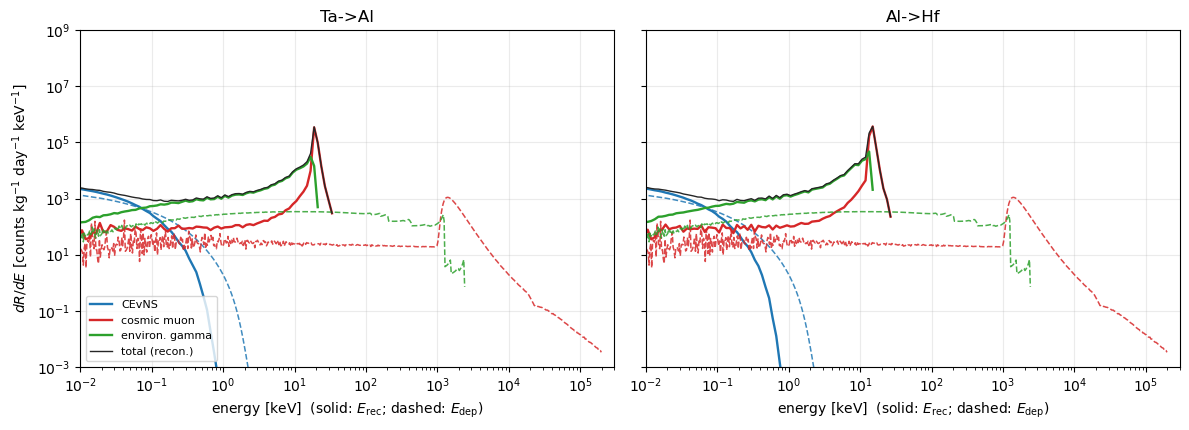

In [15]:
# Deposited (true) spectra -- design-independent; produced by the fold readers.
_cev = fold.read_cevns()
_mu  = fold.read_channel_dRdEdep(fold.MUON_CSV)
_cp  = fold.read_channel_dRdEdep(fold.COMPTON_CSV)
deposited = {"cevns":   (_cev["T_eV"]/1e3,    _cev["dRdT_total"]),
             "muon":    (_mu["E_dep_eV"]/1e3, _mu["dRdEdep"]),
             "compton": (_cp["E_dep_eV"]/1e3, _cp["dRdEdep"])}
colors = {"cevns": "#1f77b4", "muon": "#d62728", "compton": "#2ca02c"}
labels = {"cevns": "CEvNS", "muon": "cosmic muon", "compton": "environ. gamma"}
print("deposited muon E_dep range [keV]: %.3g - %.3g  (up to the 197 MeV endpoint)"
      % (deposited["muon"][0].min(), deposited["muon"][0].max()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)
for ax, design in zip(axes, ("Ta->Al", "Al->Hf")):
    s = fold._read_recon_csv(design); E = s["E_rec_keV"]
    for ch in ("cevns", "muon", "compton"):
        dx, dy = deposited[ch]; md_ = dy > 0
        ax.plot(dx[md_], dy[md_], color=colors[ch], lw=1.1, ls="--", alpha=0.85)  # deposited (true)
        y = s[f"{ch}_dRdErec"]; mr = y > 0
        ax.plot(E[mr], y[mr], color=colors[ch], lw=1.7, label=labels[ch])          # reconstructed
    yt = s["total_dRdErec"]; mt = yt > 0
    ax.plot(E[mt], yt[mt], color="0.15", lw=1.0, label="total (recon.)")
    ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(1e-2, 3e5); ax.set_ylim(1e-3, 1e9)
    ax.set_xlabel(r"energy [keV]  (solid: $E_{\rm rec}$; dashed: $E_{\rm dep}$)"); ax.set_title(design)
    ax.grid(True, which="major", alpha=0.25)
axes[0].set_ylabel(r"$dR/dE$ [counts kg$^{-1}$ day$^{-1}$ keV$^{-1}$]")
axes[0].legend(loc="lower left", fontsize=8)
plt.tight_layout(); plt.show()

## 7. Summary: computed vs. paper-quoted anchors

Every anchor above was reproduced by calling the pipeline directly. Notes:
- The muon rate uses a modest 2e6-sample MC, so it agrees with the paper's 1.366 Hz (N=1e9) to
  within MC error; the reconstructed-spectrum figures use the committed higher-statistics artifacts.
- The response matrix and reconstructed spectra are loaded from committed artifacts rather than
  rebuilt (rebuilding is 5000 forward realizations x 584 deposit energies per design).
- The saturated-regime response and the environmental-gamma normalization carry the modeling
  caveats stated in the paper; the notebook reproduces the numbers, not their interpretation.

In [16]:
print("All key anchors reproduced from src/qpd_potential/ — see the per-section checks above.")
# RETRACTED 2026-07-22 (user decision; ROADMAP Phase 10). The former project rule
# "Nothing below 10 eV is displayed on any spectrum" is HISTORY, not physics. It is
# kept here only as a dated retraction so the change is auditable, and it must never
# be restated as a live rule (ROADMAP Phase 10 forbidden proxy).
from qpd_potential.trigger import SUBEV_REGIME_BOUNDARY_eV, REGIME_STATEMENT
print("RETRACTED 2026-07-22: the former 'nothing below 10 eV' display rule no longer applies.")
print("Spectra now run down to 100 meV (v2.0 shared grid: 744 bins, floor 0.0999350 eV,")
print("first bin centre 0.1013838 eV; the v1.0 584-bin edge set is preserved exactly).")
print(f"Below {SUBEV_REGIME_BOUNDARY_eV:g} eV deposit the REPORTED observable is the trigger probability")
print("P_trig(E_dep), not the differential rate dR/dE_rec (CONVENTIONS Section I).")
print(REGIME_STATEMENT)


All key anchors reproduced from src/qpd_potential/ — see the per-section checks above.
RETRACTED 2026-07-22: the former 'nothing below 10 eV' display rule no longer applies.
Spectra now run down to 100 meV (v2.0 shared grid: 744 bins, floor 0.0999350 eV,
first bin centre 0.1013838 eV; the v1.0 584-bin edge set is preserved exactly).
Below 1 eV deposit the REPORTED observable is the trigger probability
P_trig(E_dep), not the differential rate dR/dE_rec (CONVENTIONS Section I).
Below 1 eV deposited energy the reported observable is the trigger probability P_trig(E_dep), not the differential rate dR/dE_rec: at that scale dR/dE_rec presupposes the lumped eps ~= 0.5 collection efficiency (CONVENTIONS Section E), which is not defensible for a deposit of a few optical-phonon quanta in Ge (USER DECISION 2026-07-22).


## Trigger 50% point moved to 1.0 eV (2026-07-23)

`params.TRIGGER_E50` was changed from **0.5 eV to 1.0 eV** by user decision, superseding both the
2026-07-22 decision and ROADMAP Phase 10 Success Criterion 4 (which asserts the 50% point is
"exactly at 0.5 eV").

Two things to keep straight, both of which have bitten this project before:

1. **E50 lives on the DEPOSIT axis.** The deposit -> reconstructed slope is ~0.5, so the curve's
   half-point appears near **~0.5 eV reconstructed**, not 1.0 eV. Quoting E50 against a
   reconstructed-energy axis is the cross-axis error Phase 14 flagged.
2. **E50 now COINCIDES with the sub-eV regime boundary at 1.0 eV.** They are different quantities.
   Before this change the boundary sat strictly above E50, which is what made "report dR/dE above
   the boundary" safe -- the trigger was near-unity there. It no longer is: P_trig at the boundary
   is now exactly 1/2.


In [ ]:
from qpd_potential import params, trigger

e50 = params.TRIGGER_E50.value
print(f"TRIGGER_E50 = {e50:g} eV   ({params.TRIGGER_E50.source})")

# The CONVENTIONS Section I hand-checkable values are IDENTITIES in E50 at k = 4,
# so they are unchanged by the move -- only the energies they sit at moved.
for label, E, expect in (("P(E50/2)", e50 / 2, 1 / 17),
                         ("P(E50)  ", e50,     1 / 2),
                         ("P(2*E50)", 2 * e50, 16 / 17)):
    got = float(trigger.P_trig(E))
    print(f"  {label} = P({E:5.3g} eV) = {got:.6f}   expected {expect:.6f}")
    assert abs(got - expect) < 1e-12

# The collision, asserted rather than described.
b = trigger.SUBEV_REGIME_BOUNDARY_eV
print(f"\nregime boundary = {b:g} eV,  E50 = {e50:g} eV  ->  they now COINCIDE")
print(f"P_trig(boundary) = {float(trigger.P_trig(b)):.4f}")
print("i.e. dR/dE_rec is reported from an energy at which HALF the events do not trigger.")
print("Recovering the boundary's original meaning (P_trig >= 0.99 at k = 4) would put it at")
print(f"  {e50 * (1/0.01 - 1)**0.25:.2f} eV -- a separate decision, not made here.")
